In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [278]:
data_df = pd.read_csv("../data/raw/Customer-Churn.csv")

customer_df = data_df.copy()

In [279]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [280]:
customer_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [281]:
customer_df.shape

(7043, 21)

In [282]:
customer_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [283]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [284]:
for column in customer_df.columns:
    print(f"la columna {column} cuenta con : {customer_df[column].nunique()}")
    print(f"{customer_df[column].unique()}\n\n")

la columna customerID cuenta con : 7043
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str


la columna gender cuenta con : 2
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


la columna SeniorCitizen cuenta con : 2
[0 1]


la columna Partner cuenta con : 2
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


la columna Dependents cuenta con : 2
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


la columna tenure cuenta con : 73
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


la columna PhoneService cuenta con : 2
<StringArray>
['No

In [285]:
for columna in customer_df.columns:
    duplicados = customer_df.duplicated().sum()
    nulls = customer_df[columna].isna().sum()
    print(f"la columna : {columna} tiene {duplicados} duplicados y {nulls} nulos ")

la columna : customerID tiene 0 duplicados y 0 nulos 
la columna : gender tiene 0 duplicados y 0 nulos 
la columna : SeniorCitizen tiene 0 duplicados y 0 nulos 
la columna : Partner tiene 0 duplicados y 0 nulos 
la columna : Dependents tiene 0 duplicados y 0 nulos 
la columna : tenure tiene 0 duplicados y 0 nulos 


la columna : PhoneService tiene 0 duplicados y 0 nulos 
la columna : MultipleLines tiene 0 duplicados y 0 nulos 
la columna : InternetService tiene 0 duplicados y 0 nulos 
la columna : OnlineSecurity tiene 0 duplicados y 0 nulos 
la columna : OnlineBackup tiene 0 duplicados y 0 nulos 
la columna : DeviceProtection tiene 0 duplicados y 0 nulos 
la columna : TechSupport tiene 0 duplicados y 0 nulos 
la columna : StreamingTV tiene 0 duplicados y 0 nulos 
la columna : StreamingMovies tiene 0 duplicados y 0 nulos 
la columna : Contract tiene 0 duplicados y 0 nulos 
la columna : PaperlessBilling tiene 0 duplicados y 0 nulos 
la columna : PaymentMethod tiene 0 duplicados y 0 nulos 
la columna : MonthlyCharges tiene 0 duplicados y 0 nulos 
la columna : TotalCharges tiene 0 duplicados y 0 nulos 
la columna : Churn tiene 0 duplicados y 0 nulos 


In [286]:
for column in customer_df.select_dtypes(include=["object","string"]).columns :
    empty = customer_df[column].str.strip().eq("").sum()
    if empty > 0:
        print(f"la columna {column} cuenta con : {empty}, valores vacios vacias")
    

la columna TotalCharges cuenta con : 11, valores vacios vacias


In [287]:
CantidadVacia = customer_df["TotalCharges"].str.strip().eq("").sum()
Total = customer_df["TotalCharges"].shape[0]

print(f"el porcentaje de datos vacios son :{((CantidadVacia/Total)*100).round(2)} %")

el porcentaje de datos vacios son :0.16 %


In [288]:
customer_df.loc[
    customer_df["TotalCharges"].str.strip().eq(""),
    ["customerID","tenure","MonthlyCharges","TotalCharges", "Contract", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [289]:
customer_df["TotalCharges"] = customer_df["TotalCharges"].replace(" ", np.nan)
customer_df["TotalCharges"].isna().sum()

np.int64(11)

In [290]:
customer_df["TotalCharges"] = customer_df["TotalCharges"].astype(float)
customer_df["TotalCharges"].dtype

dtype('float64')

In [291]:
customer_df = customer_df.dropna(subset=["TotalCharges"])
customer_df = customer_df.reset_index(drop=True)
customer_df["TotalCharges"].isna().sum()

np.int64(0)

In [292]:
customer_df["SeniorCitizen"] = customer_df["SeniorCitizen"].replace({1:"Yes",0:"No"})


In [293]:
columnas_NIS = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for columna in columnas_NIS:
    customer_df[columna] = customer_df[columna].replace({"No internet service":"No"})

In [294]:
columnas_NIS = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for columna in columnas_NIS:
    empty = (customer_df[columna] == "No internet service").sum()
    print(f"{empty}")

0
0
0
0
0
0


In [295]:
Columa_Categoria = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "InternetService", 
                    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", 
                    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "Churn"]
for column in Columa_Categoria:
    customer_df[column] = customer_df[column].astype("category")

customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   str     
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   str     
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-null   c

In [296]:
customer_df[["tenure","MonthlyCharges","TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


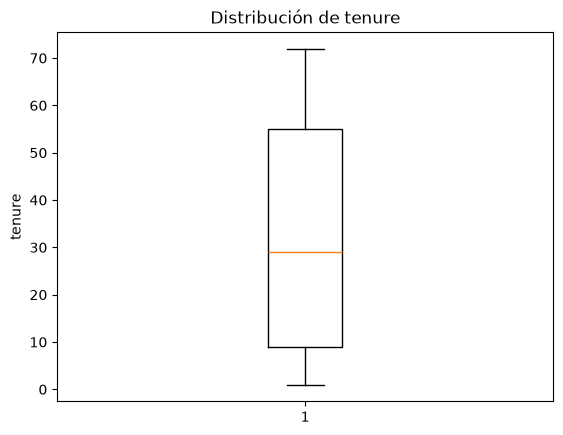

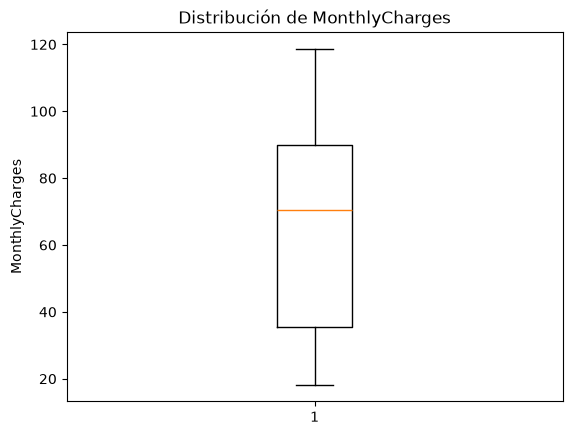

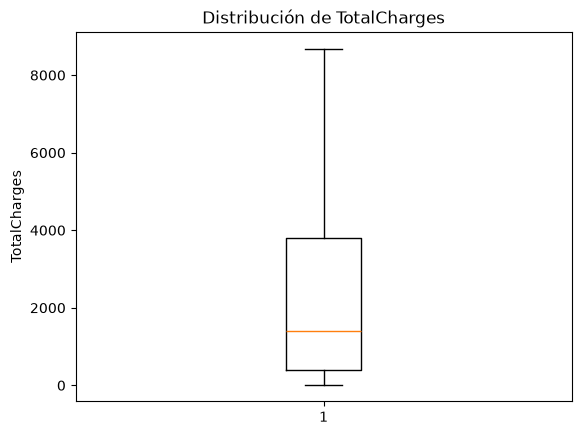

In [297]:
columnas_num = ["tenure","MonthlyCharges","TotalCharges"]

def analisis_columnas(df, columna):

    plt.Figure(figsize=(6,4))
    plt.boxplot(df[columna].dropna(), orientation="vertical")
    plt.title(f"Distribución de {columna}")
    plt.ylabel(f"{columna}")
    plt.show()

for columna in columnas_num:
    analisis_columnas(customer_df, columna)

La columna gender presenta : gender
Female    3483
Male      3549
Name: count, dtype: int64


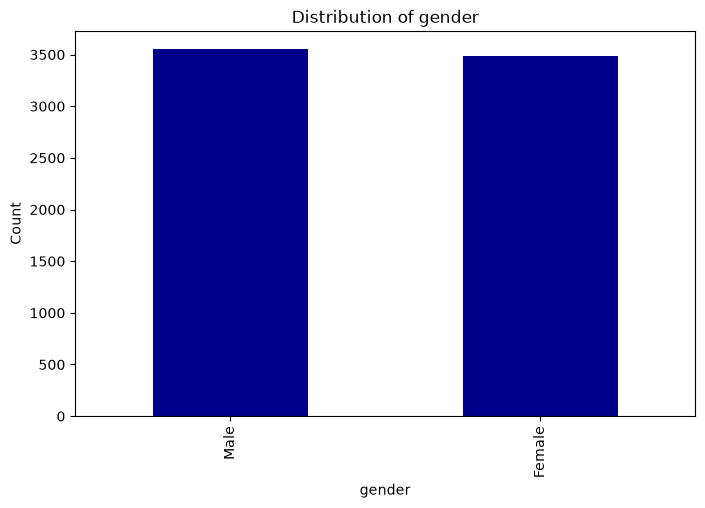

La columna SeniorCitizen presenta : SeniorCitizen
Yes    1142
No     5890
Name: count, dtype: int64


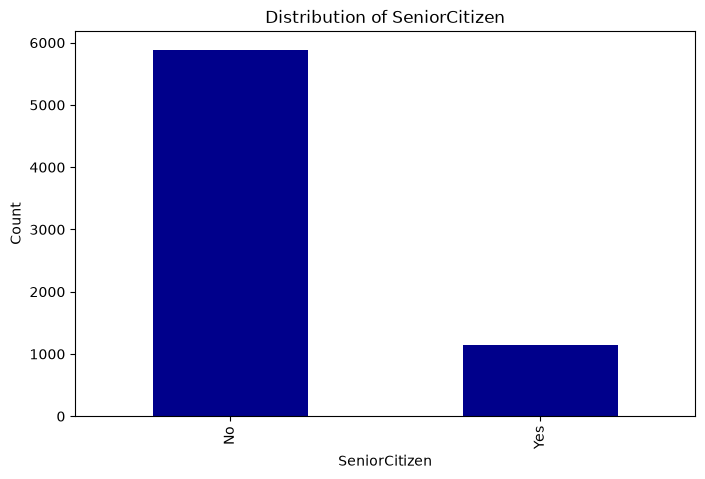

La columna Partner presenta : Partner
Yes    3393
No     3639
Name: count, dtype: int64


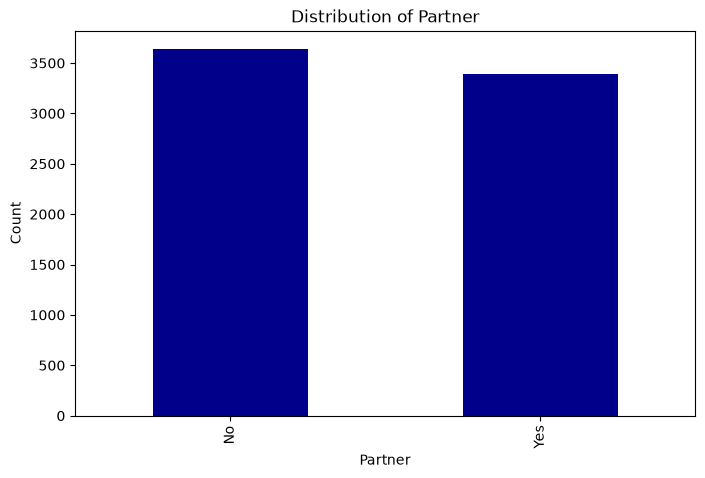

La columna Dependents presenta : Dependents
Yes    2099
No     4933
Name: count, dtype: int64


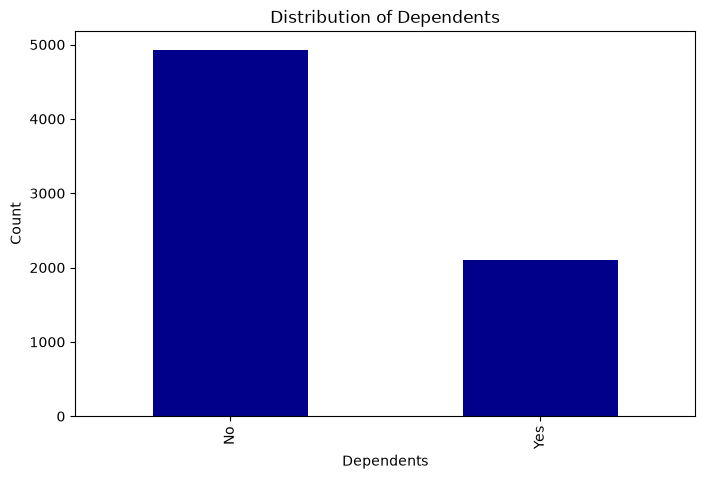

La columna PhoneService presenta : PhoneService
No      680
Yes    6352
Name: count, dtype: int64


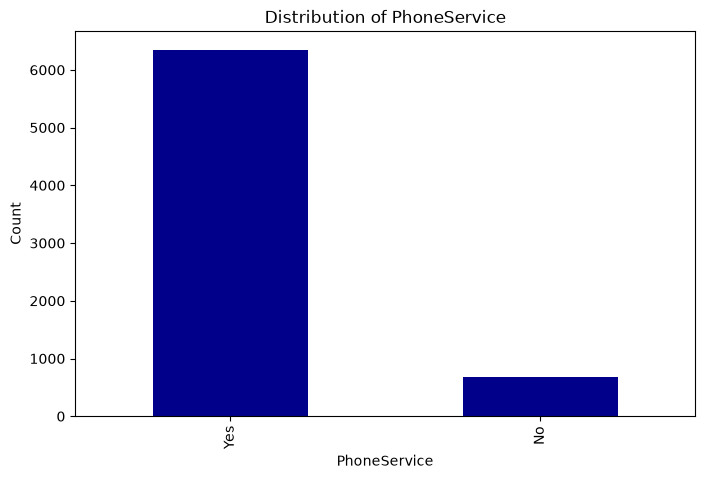

La columna MultipleLines presenta : MultipleLines
No phone service     680
Yes                 2967
No                  3385
Name: count, dtype: int64


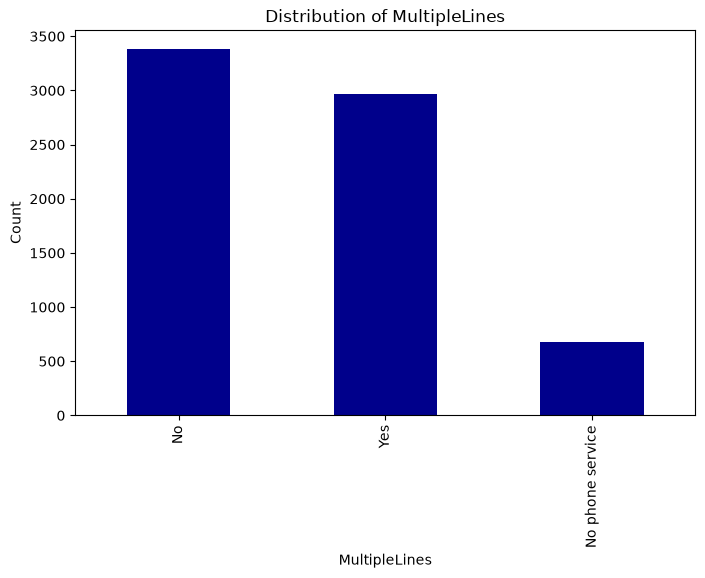

La columna InternetService presenta : InternetService
No             1520
DSL            2416
Fiber optic    3096
Name: count, dtype: int64


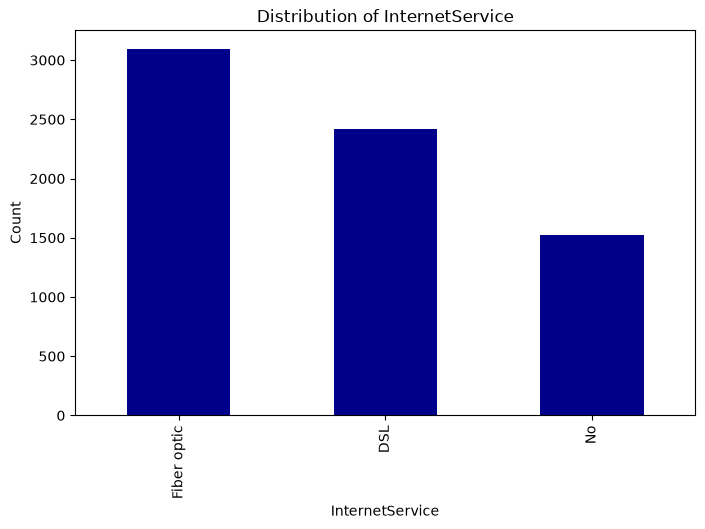

La columna OnlineSecurity presenta : OnlineSecurity
Yes    2015
No     5017
Name: count, dtype: int64


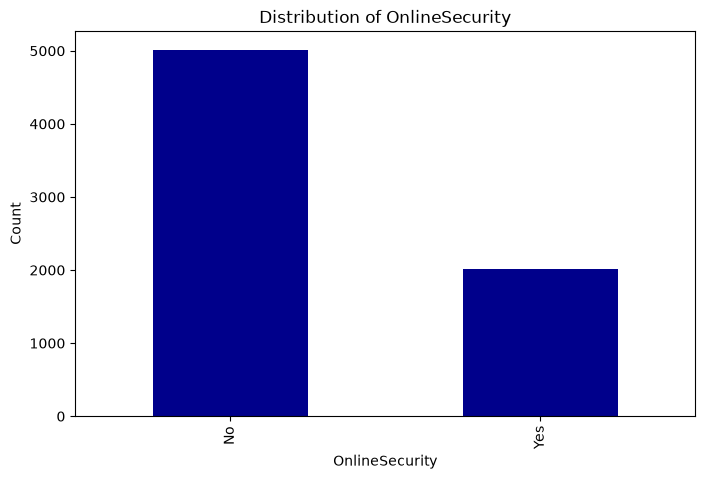

La columna OnlineBackup presenta : OnlineBackup
Yes    2425
No     4607
Name: count, dtype: int64


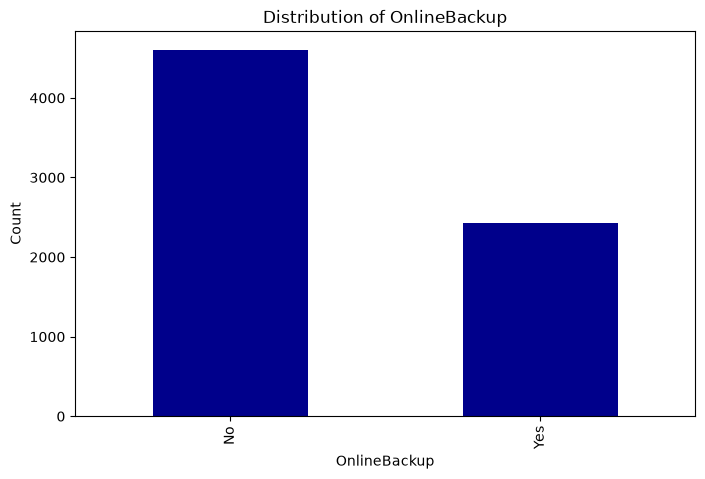

La columna DeviceProtection presenta : DeviceProtection
Yes    2418
No     4614
Name: count, dtype: int64


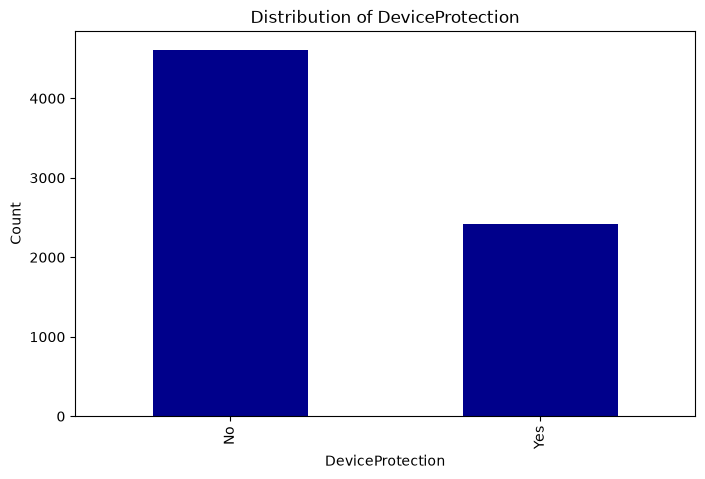

La columna TechSupport presenta : TechSupport
Yes    2040
No     4992
Name: count, dtype: int64


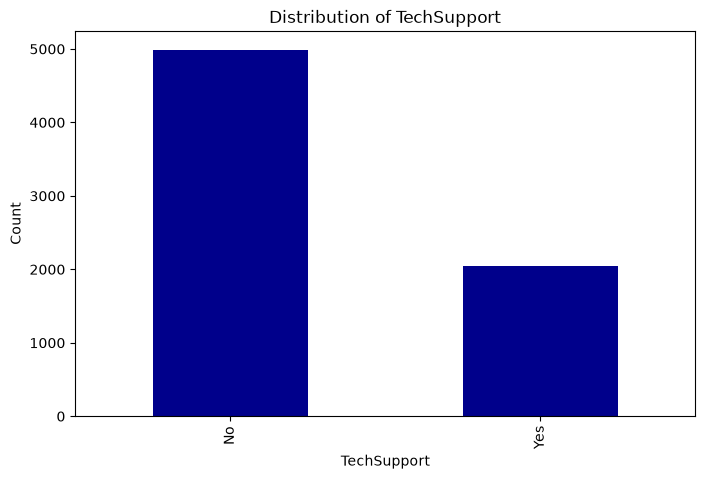

La columna StreamingTV presenta : StreamingTV
Yes    2703
No     4329
Name: count, dtype: int64


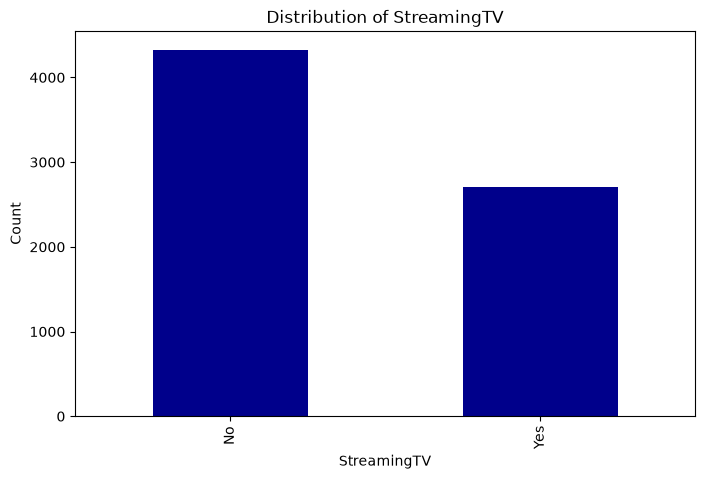

La columna StreamingMovies presenta : StreamingMovies
Yes    2731
No     4301
Name: count, dtype: int64


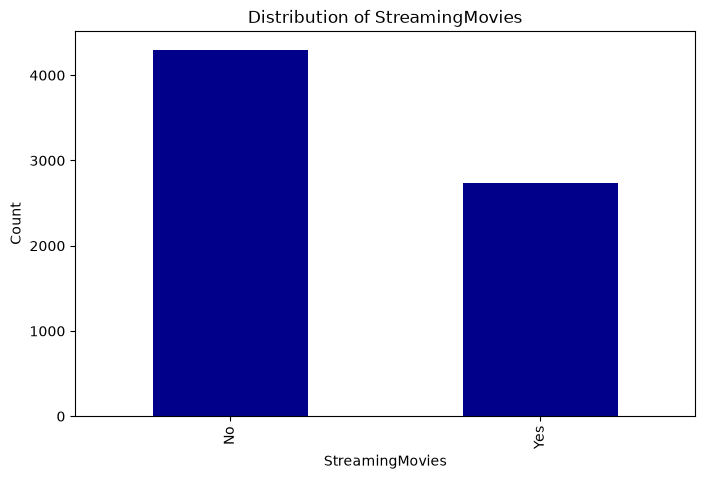

La columna Contract presenta : Contract
One year          1472
Two year          1685
Month-to-month    3875
Name: count, dtype: int64


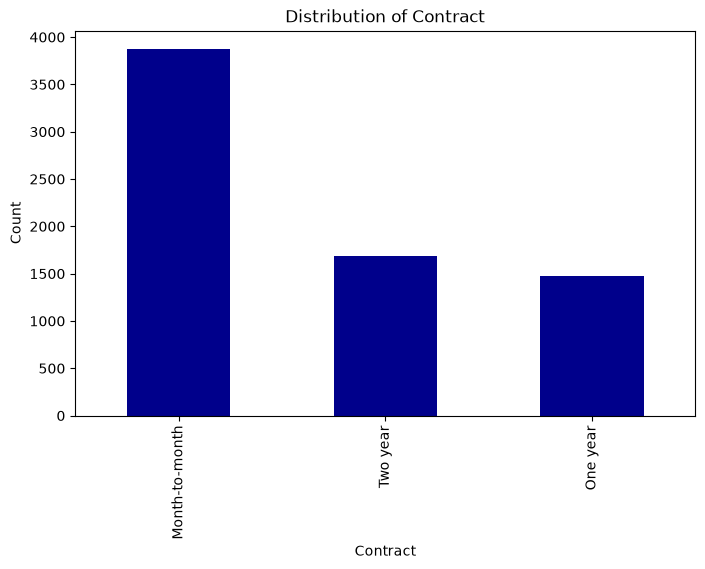

La columna PaperlessBilling presenta : PaperlessBilling
No     2864
Yes    4168
Name: count, dtype: int64


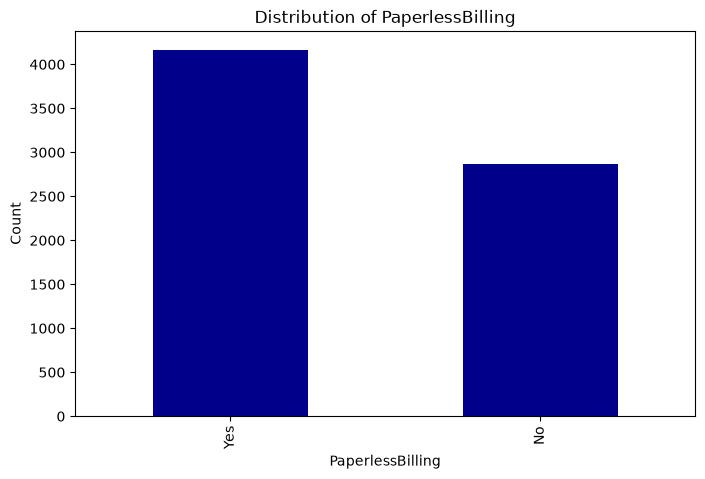

La columna PaymentMethod presenta : PaymentMethod
Credit card (automatic)      1521
Bank transfer (automatic)    1542
Mailed check                 1604
Electronic check             2365
Name: count, dtype: int64


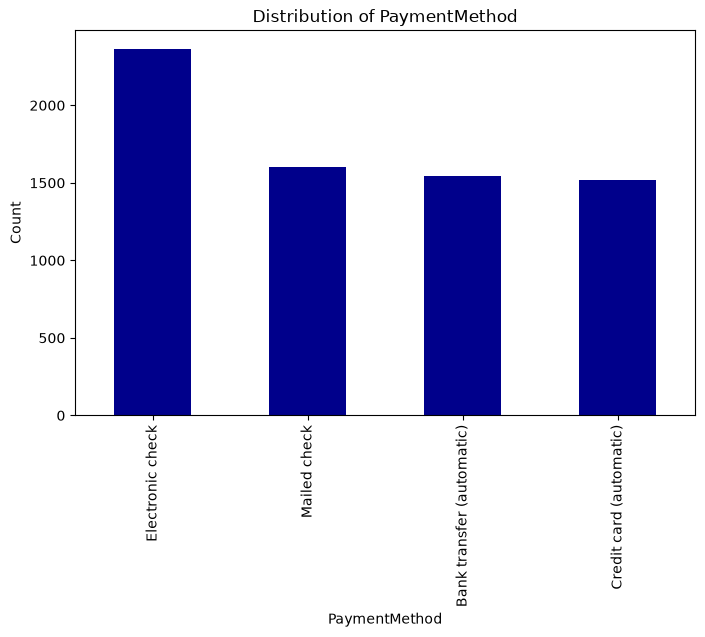

La columna Churn presenta : Churn
Yes    1869
No     5163
Name: count, dtype: int64


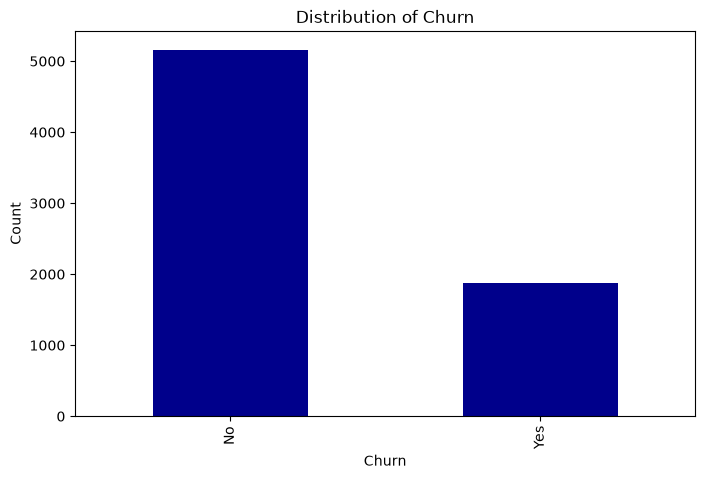

In [298]:
columnas_category = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod','Churn']

def analisis_columnas(df, columna):

    print(f"La columna {columna} presenta : {df[columna].value_counts().sort_values()}")

    df[columna].value_counts().plot(kind="bar", color="darkblue", figsize=(8,5))
    plt.title(f"Distribution of {columna}")
    plt.xlabel(f"{columna}")
    plt.ylabel("Count")
    plt.show()

for columna in columnas_category:
    analisis_columnas(customer_df, columna)

In [299]:
customer_Churn = customer_df[customer_df["Churn"].eq("No")]

(
    customer_Churn["Contract"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Contract
Month-to-month    43.00
Two year          31.71
One year          25.30
Name: proportion, dtype: float64

In [ ]:
churn_yes = customer_df[customer_df["Churn"].eq("Yes")]
churn_no = customer_df[customer_df["Churn"].eq("No")]

def analisis(column):

    tablas = [("Churm Yes",churn_yes),("Churm No",churn_no)]

    for titulo, tabla in tablas:

        tb = tabla[column].value_counts(normalize=True).mul(100).round(2)

        print(tb)

        ax = tb.plot(kind="bar")
        ax.bar_label( ax.containers[0],fmt="%.1f%%")
        plt.xticks(rotation=0)
        plt.title(f" {column} - {titulo}")
        plt.ylabel("Porcentaje")
        plt.show()

SeniorCitizen
No     74.53
Yes    25.47
Name: proportion, dtype: float64


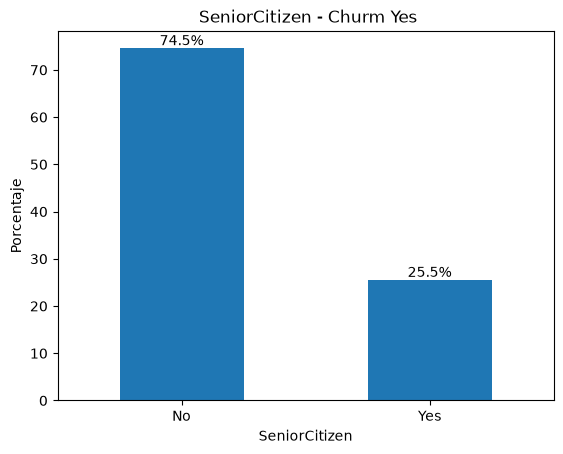

SeniorCitizen
No     87.1
Yes    12.9
Name: proportion, dtype: float64


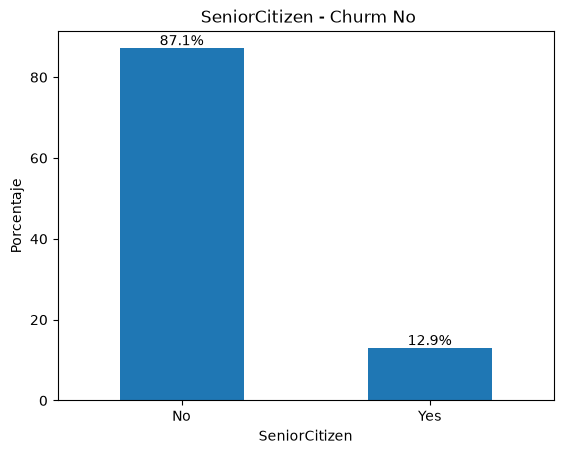

In [301]:
analisis("SeniorCitizen")

Partner
No     64.21
Yes    35.79
Name: proportion, dtype: float64


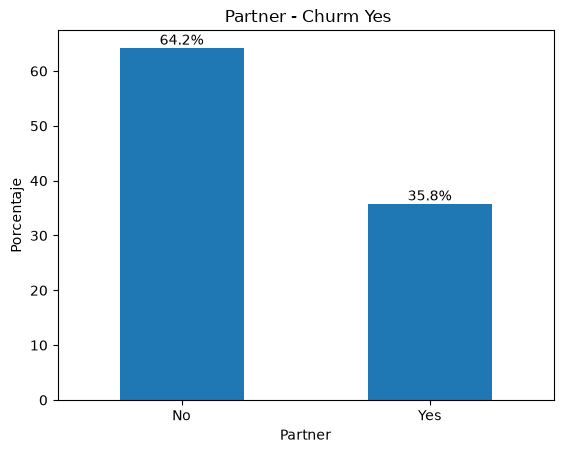

Partner
Yes    52.76
No     47.24
Name: proportion, dtype: float64


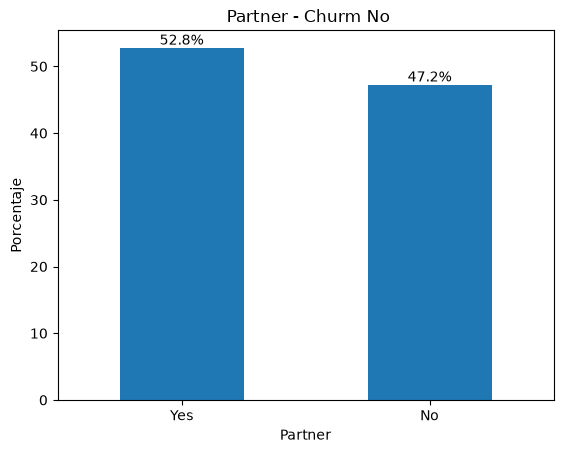

In [302]:
analisis("Partner")

Dependents
No     82.56
Yes    17.44
Name: proportion, dtype: float64


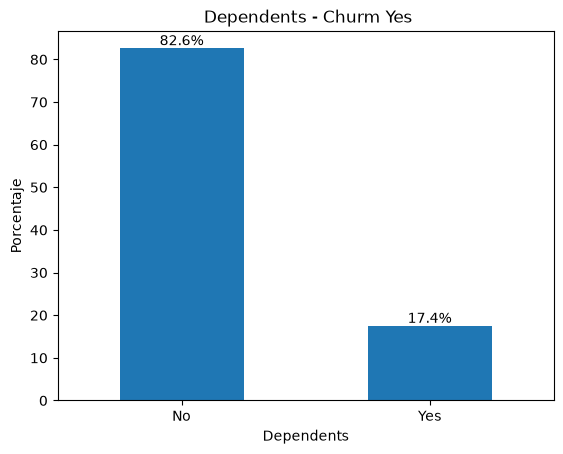

Dependents
No     65.66
Yes    34.34
Name: proportion, dtype: float64


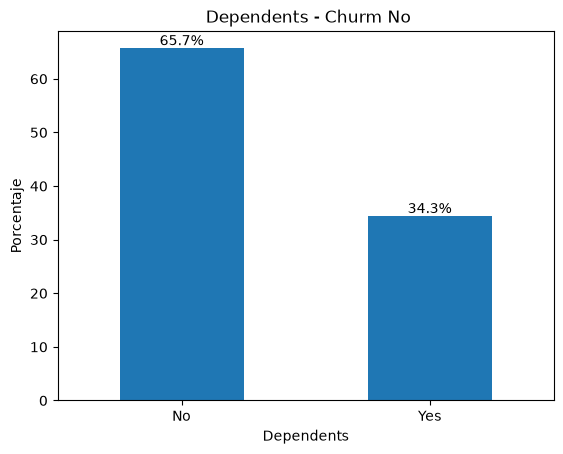

In [303]:
analisis("Dependents")

PhoneService
Yes    90.9
No      9.1
Name: proportion, dtype: float64


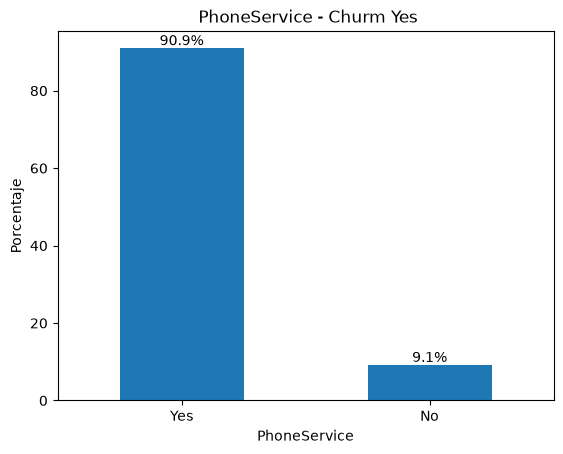

PhoneService
Yes    90.12
No      9.88
Name: proportion, dtype: float64


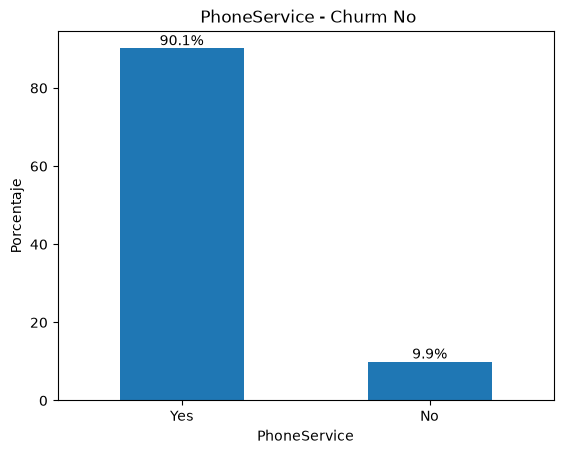

In [304]:
analisis("PhoneService")

MultipleLines
Yes                 45.48
No                  45.43
No phone service     9.10
Name: proportion, dtype: float64


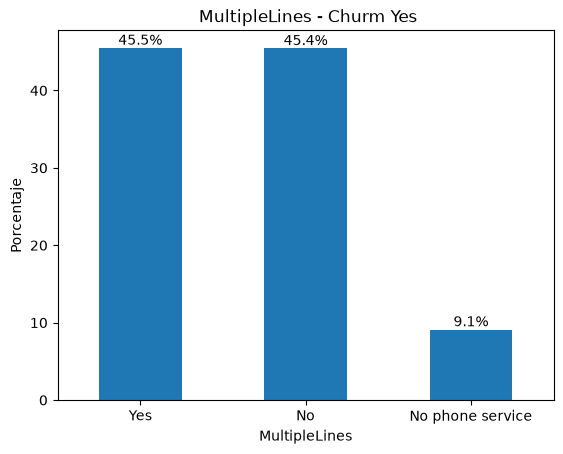

MultipleLines
No                  49.12
Yes                 41.00
No phone service     9.88
Name: proportion, dtype: float64


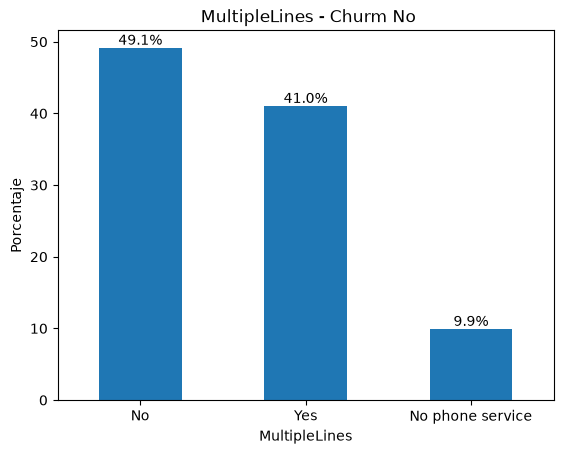

In [305]:
analisis("MultipleLines")

InternetService
Fiber optic    69.40
DSL            24.56
No              6.05
Name: proportion, dtype: float64


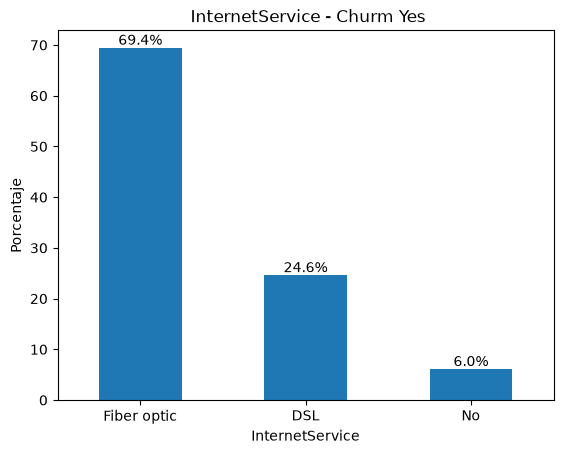

InternetService
DSL            37.90
Fiber optic    34.84
No             27.25
Name: proportion, dtype: float64


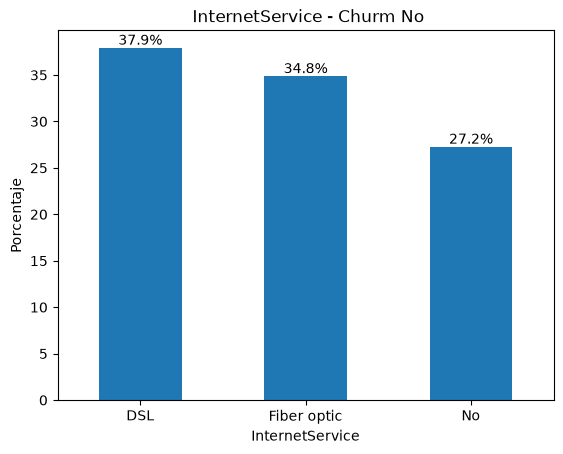

In [306]:
analisis("InternetService")

OnlineSecurity
No     84.22
Yes    15.78
Name: proportion, dtype: float64


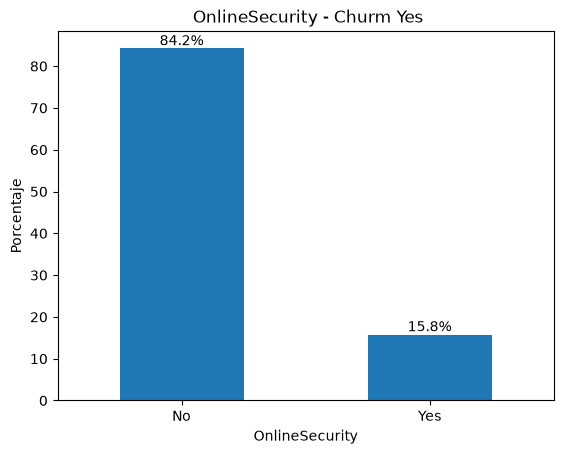

OnlineSecurity
No     66.69
Yes    33.31
Name: proportion, dtype: float64


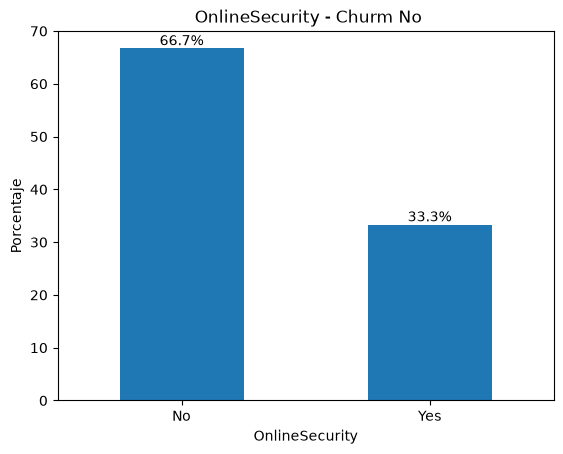

In [307]:
analisis("OnlineSecurity")

DeviceProtection
No     70.84
Yes    29.16
Name: proportion, dtype: float64


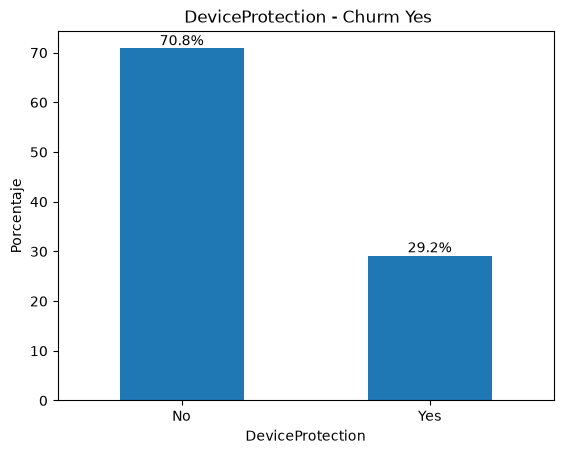

DeviceProtection
No     63.72
Yes    36.28
Name: proportion, dtype: float64


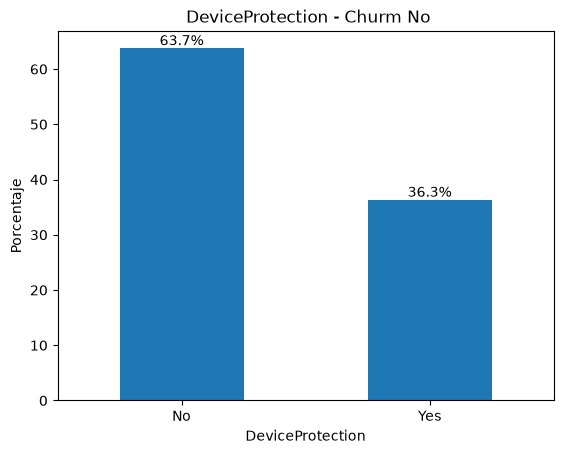

In [308]:
analisis("DeviceProtection")

TechSupport
No     83.41
Yes    16.59
Name: proportion, dtype: float64


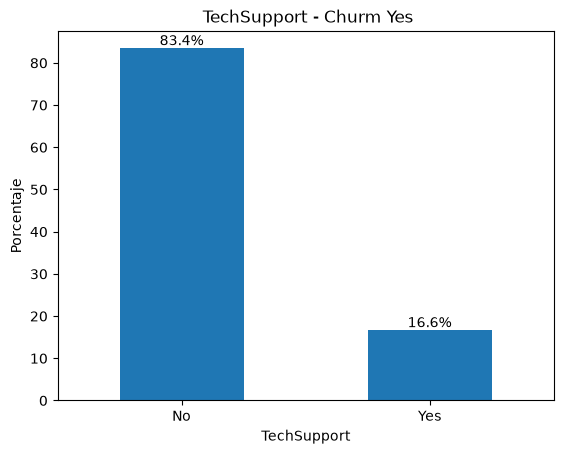

TechSupport
No     66.49
Yes    33.51
Name: proportion, dtype: float64


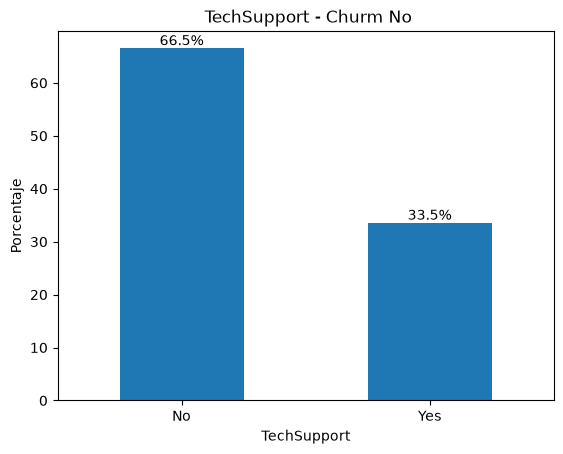

In [309]:
analisis("TechSupport")

StreamingTV
No     56.45
Yes    43.55
Name: proportion, dtype: float64


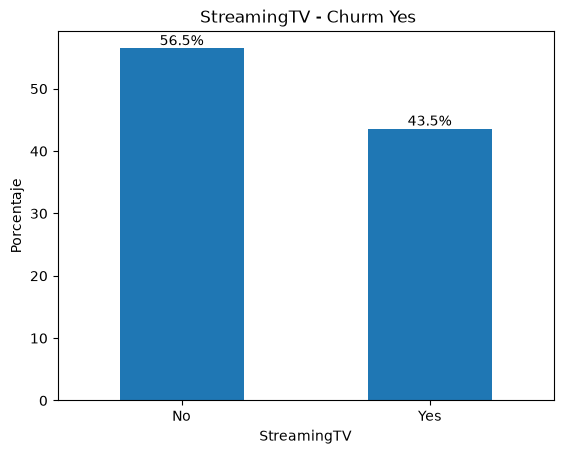

StreamingTV
No     63.41
Yes    36.59
Name: proportion, dtype: float64


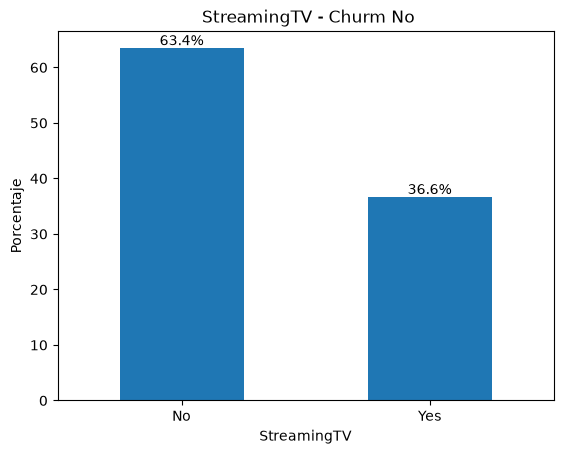

In [310]:
analisis("StreamingTV")

StreamingMovies
No     56.23
Yes    43.77
Name: proportion, dtype: float64


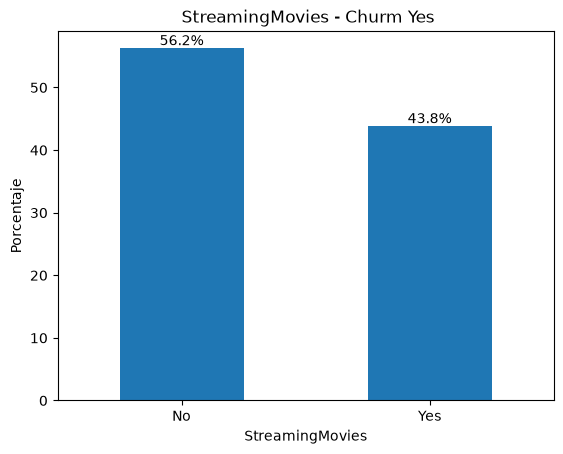

StreamingMovies
No     62.95
Yes    37.05
Name: proportion, dtype: float64


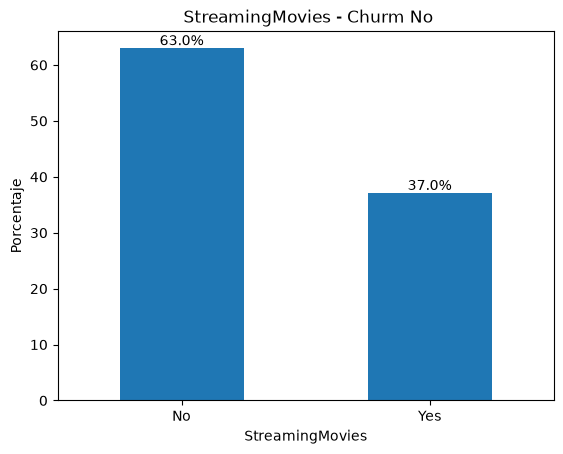

In [311]:
analisis("StreamingMovies")

Contract
Month-to-month    88.55
One year           8.88
Two year           2.57
Name: proportion, dtype: float64


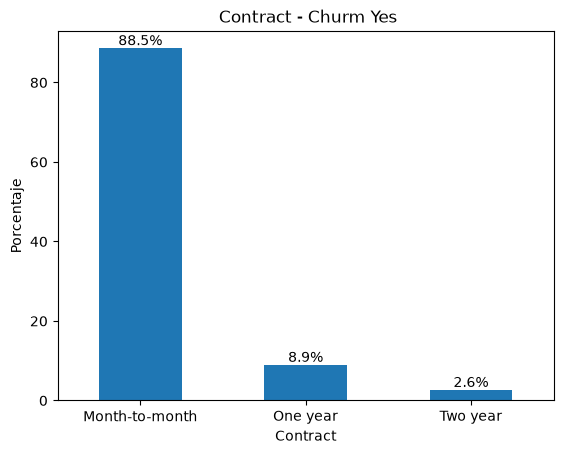

Contract
Month-to-month    43.00
Two year          31.71
One year          25.30
Name: proportion, dtype: float64


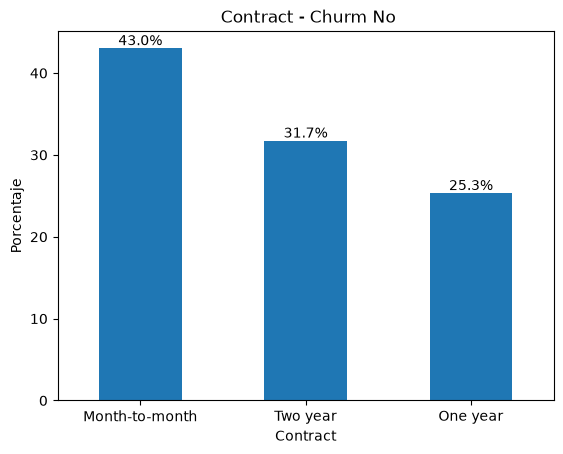

In [312]:
analisis("Contract")

PaperlessBilling
Yes    74.91
No     25.09
Name: proportion, dtype: float64


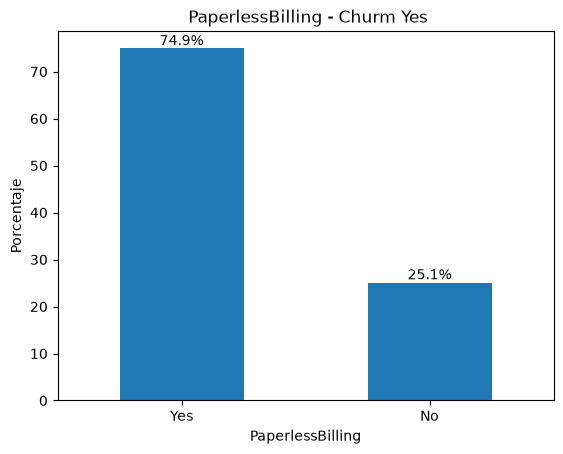

PaperlessBilling
Yes    53.61
No     46.39
Name: proportion, dtype: float64


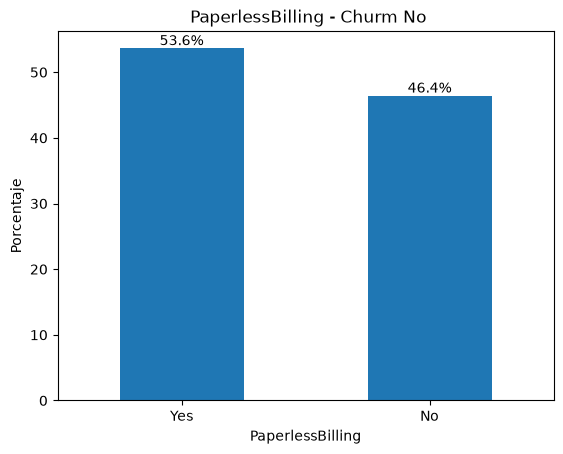

In [313]:
analisis("PaperlessBilling")

PaymentMethod
Electronic check             57.30
Mailed check                 16.48
Bank transfer (automatic)    13.80
Credit card (automatic)      12.41
Name: proportion, dtype: float64


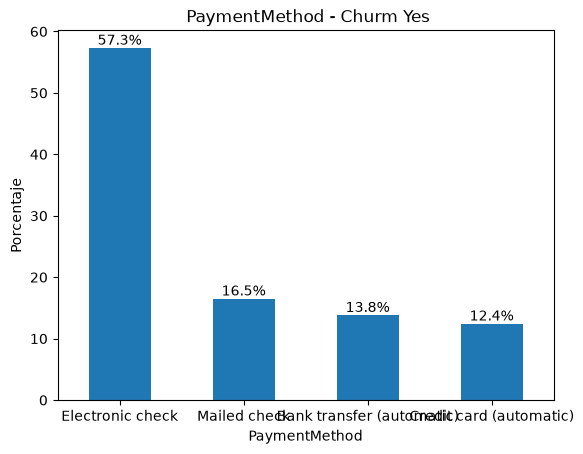

PaymentMethod
Mailed check                 25.10
Electronic check             25.06
Credit card (automatic)      24.97
Bank transfer (automatic)    24.87
Name: proportion, dtype: float64


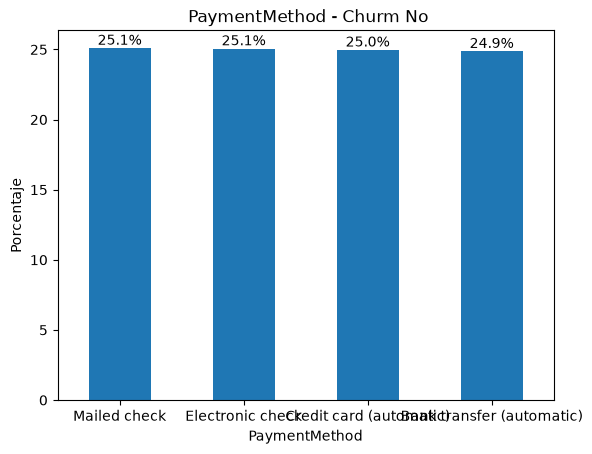

In [ ]:
analisis("PaymentMethod")

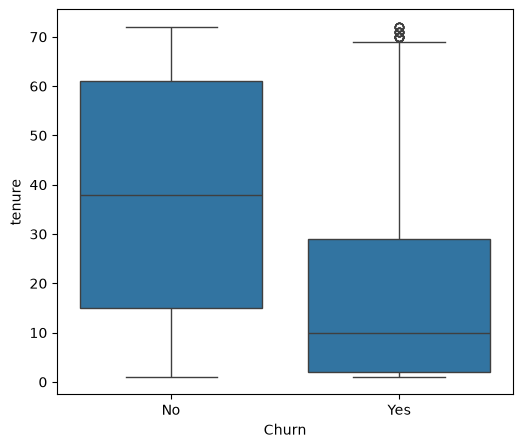

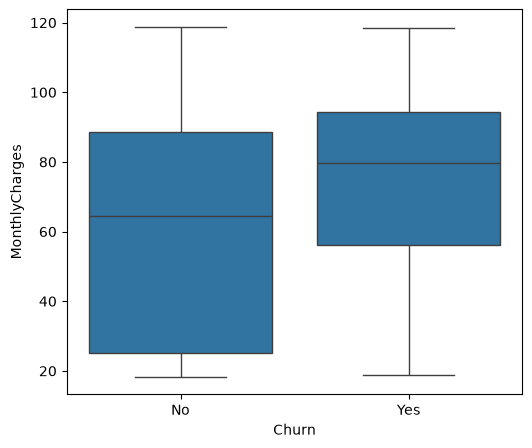

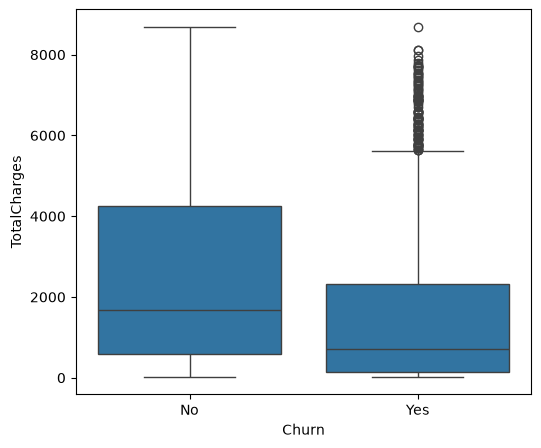

In [324]:
columnas_num = ["tenure","MonthlyCharges","TotalCharges"]

def analisis_columnas(df, columna):

    fig = plt.figure(figsize=(20,5))
    fig.add_subplot(131)
    sns.boxplot(data=df, x="Churn", y=columna)
    plt.show()


for columna in columnas_num:
    analisis_columnas(customer_df, columna)

In [325]:
customer_df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)

tenure                       MonthlyCharges                       \
        mean median    std min max           mean median    std    min   
Churn                                                                    
No     37.65   38.0  24.08   1  72          61.31  64.45  31.09  18.25   
Yes    17.98   10.0  19.53   1  72          74.44  79.65  24.67  18.85   

              TotalCharges                                    
          max         mean   median      std    min      max  
Churn                                                         
No     118.75      2555.34  1683.60  2329.46  18.80  8672.45  
Yes    118.35      1531.80   703.55  1890.82  18.85  8684.80